In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
df = pd.read_csv("xy_data.csv")

# Display first few rows
print(df.head())

# Dataset information
print("\nDataset Info:")
print(df.info())

# Basic statistics
print("\nStatistics:")
print(df.describe())

            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       1500 non-null   float64
 1   y       1500 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB
None

Statistics:
                 x            y
count  1500.000000  1500.000000
mean     83.713931    58.263519
std      13.697157     7.696524
min      59.657204    46.032295
25%      72.282910    51.124211
50%      84.710995    57.681288
75%      93.368257    66.138374
max     109.231520    69.685510


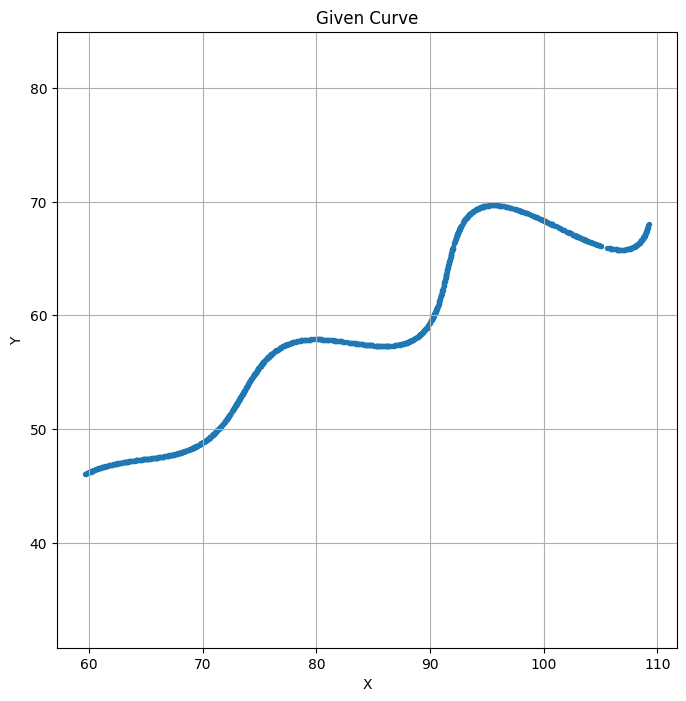

In [2]:
plt.figure(figsize=(8,8))

plt.scatter(df["x"], df["y"], s=8)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Given Curve")
plt.grid(True)
plt.axis("equal")

plt.show()

In [3]:
display(df.head(20))

,x,y
0,88.364456,57.784378
1,74.283936,54.406780
2,60.256474,46.311462
3,82.134370,57.717567
4,101.036390,67.849340
5,69.284134,48.406086
6,77.810130,57.588833
7,91.296880,63.031350
8,107.668410,65.914050
9,76.406890,56.871525


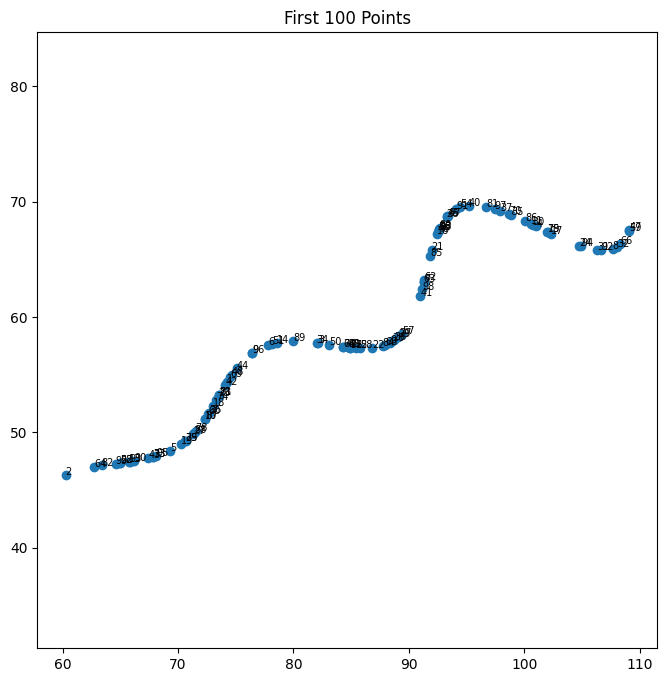

In [4]:
plt.figure(figsize=(8,8))

plt.scatter(df["x"][:100], df["y"][:100])

for i in range(100):
    plt.text(df["x"][i], df["y"][i], str(i), fontsize=7)

plt.title("First 100 Points")
plt.axis("equal")
plt.show()

In [5]:
t = np.linspace(6, 60, len(df))

print(t[:10])
print(t[-10:])

[6.         6.03602402 6.07204803 6.10807205 6.14409606 6.18012008
 6.2161441  6.25216811 6.28819213 6.32421614]
[59.67578386 59.71180787 59.74783189 59.7838559  59.81987992 59.85590394
 59.89192795 59.92795197 59.96397598 60.        ]


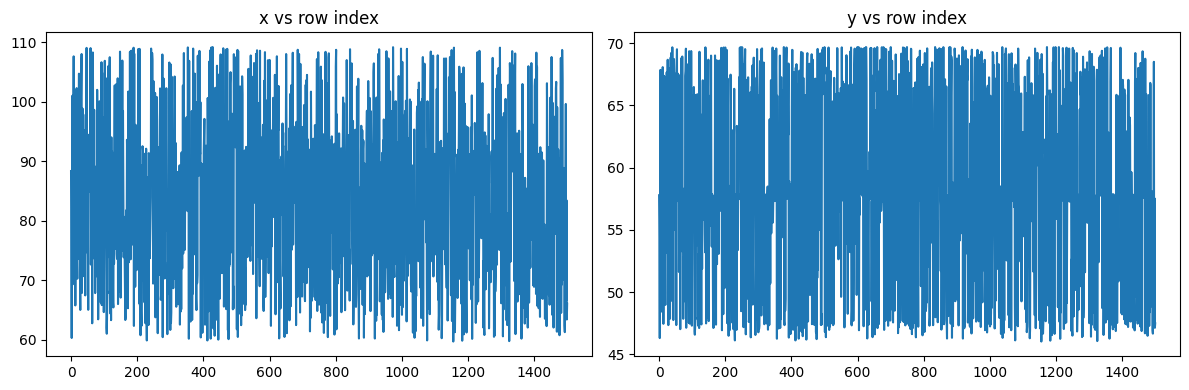

In [6]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(df["x"])
plt.title("x vs row index")

plt.subplot(1,2,2)
plt.plot(df["y"])
plt.title("y vs row index")

plt.tight_layout()
plt.show()

In [8]:
pip install scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import numpy as np

def generate_curve(theta_deg, M, X, n_points=3000):
    theta = np.deg2rad(theta_deg)
    t = np.linspace(6, 60, n_points)

    x = (
        t * np.cos(theta)
        - np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.sin(theta)
        + X
    )

    y = (
        42
        + t * np.sin(theta)
        + np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.cos(theta)
    )

    return np.column_stack((x, y))

In [10]:
points = df[["x", "y"]].to_numpy()

In [11]:
from scipy.spatial import cKDTree

def loss(params):
    theta, M, X = params

    curve = generate_curve(theta, M, X)

    tree = cKDTree(curve)

    distances, _ = tree.query(points)

    return np.sum(distances)

In [12]:
from scipy.optimize import differential_evolution

bounds = [
    (0, 50),      # theta
    (-0.05, 0.05),# M
    (0, 100)      # X
]

result = differential_evolution(
    loss,
    bounds,
    seed=42
)

print(result)

             message: Optimization terminated successfully.
             success: True
                 fun: 8.219646999974826
                   x: [ 3.000e+01  3.000e-02  5.500e+01]
                 nit: 42
                nfev: 2055
          population: [[ 3.000e+01  3.000e-02  5.500e+01]
                       [ 3.000e+01  2.999e-02  5.500e+01]
                       ...
                       [ 3.000e+01  3.000e-02  5.500e+01]
                       [ 3.000e+01  3.000e-02  5.500e+01]]
 population_energies: [ 8.220e+00  8.418e+00 ...  8.271e+00  8.268e+00]
                 jac: [-3.917e-02  8.374e+00  1.319e-01]


In [13]:
theta, M, X = result.x

print(f"Theta = {theta:.6f}")
print(f"M = {M:.6f}")
print(f"X = {X:.6f}")

Theta = 30.000036
M = 0.030000
X = 55.000014


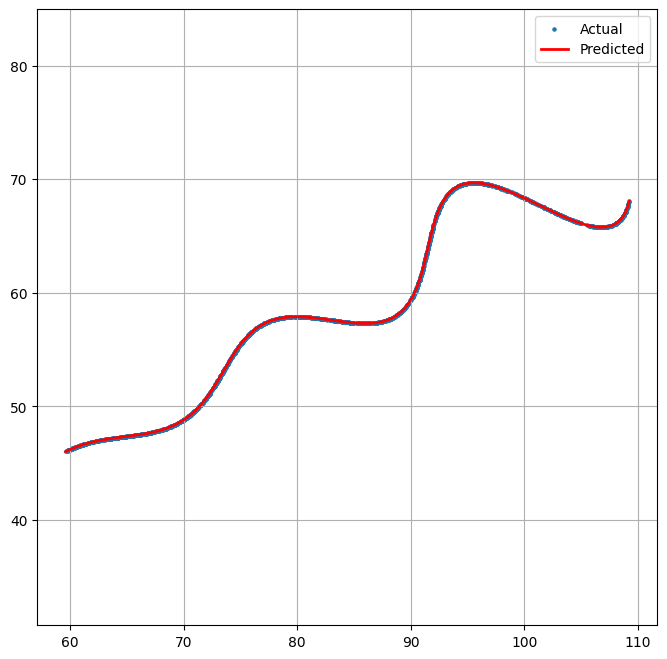

In [14]:
curve = generate_curve(theta, M, X)

plt.figure(figsize=(8,8))

plt.scatter(points[:,0], points[:,1], s=5, label="Actual")
plt.plot(curve[:,0], curve[:,1], color="red", linewidth=2, label="Predicted")

plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()

In [15]:
print(result.fun)

8.219646999974826


In [16]:
print(result.nit)
print(result.success)
print(result.message)

42
True
Optimization terminated successfully.


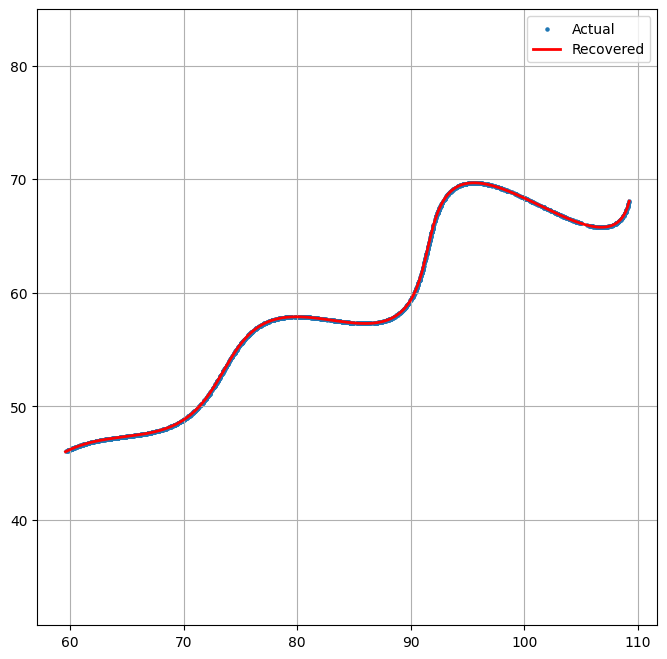

In [17]:
curve = generate_curve(30, 0.03, 55)

plt.figure(figsize=(8,8))
plt.scatter(points[:,0], points[:,1], s=5, label="Actual")
plt.plot(curve[:,0], curve[:,1], "r", linewidth=2, label="Recovered")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()